In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df= pd.read_excel("C:/Users/Disha/Desktop/project/blast_result.xlsx")

In [4]:
df

,Protein name,Organism,Sequence ID,Alignment Range,Alignment Length,Score (bits),E-value,%Identity
0,Subclass B1 beta-lactamase NDM family protein,Providencia rettgeri,XVM46651,9–278,278,557.0,0,1.0000
1,Metallo-beta-lactamase type 2,Providencia stuartii,WHE44028,1–270,270,556.2,0,1.0000
2,Subclass B1 beta-lactamase NDM family protein,Providencia rettgeri,XVM46758,36–305,305,556.2,0,1.0000
3,"Chain A, Beta-lactamase NDM-1",Klebsiella pneumoniae,4EXS_A,1–270,270,555.8,0,1.0000
4,Metallo-beta-lactamase NDM-1,Acinetobacter baumannii,ALD19783,2–271,271,555.8,0,1.0000
5,MULTISPECIES: NDM-1,Pseudomonadota,WP_004201164,1–270,270,555.8,0,1.0000
6,NDM family subclass B1 metallo-beta-lactamase,Providencia huaxiensis,WP_369466427,1–270,270,555.4,0,0.9960
7,NDM family subclass B1 metallo-beta-lactamase,Salmonella enterica,HAD9259603,1–270,270,555.1,0,0.9960
8,NDM family subclass B1 metallo-beta-lactamase,Enterobacter hormaechei subsp. xiangfangensis,HBM2817202,1–270,270,555.1,0,0.9960
9,Subclass B1 metallo-beta-lactamase NDM-58,Pseudomonas aeruginosa,WP_290468356,1-270,270,553.1,0,0.9963


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Protein name      20 non-null     object 
 1   Organism          20 non-null     object 
 2   Sequence ID       20 non-null     object 
 3   Alignment Range   20 non-null     object 
 4   Alignment Length  20 non-null     int64  
 5   Score (bits)      20 non-null     float64
 6   E-value           20 non-null     int64  
 7   %Identity         20 non-null     float64
dtypes: float64(2), int64(2), object(4)
memory usage: 1.4+ KB


In [6]:
df.isnull().sum()


Protein name        0
Organism            0
Sequence ID         0
Alignment Range     0
Alignment Length    0
Score (bits)        0
E-value             0
%Identity           0
dtype: int64

In [7]:
df.describe()

,Alignment Length,Score (bits),E-value,%Identity
count,20.000000,20.000000,20.0,20.000000
mean,272.200000,554.440000,0.0,0.997480
std,7.924645,1.432113,0.0,0.001798
min,270.000000,553.100000,0.0,0.996000
25%,270.000000,553.100000,0.0,0.996300
50%,270.000000,554.100000,0.0,0.996300
75%,270.000000,555.800000,0.0,1.000000
max,305.000000,557.000000,0.0,1.000000


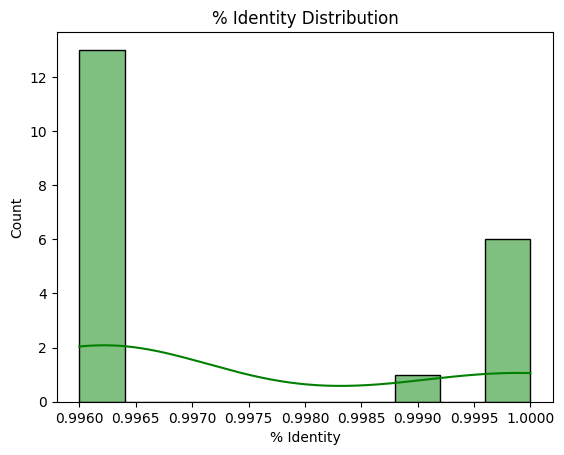

In [8]:
sns.histplot(df['%Identity'], bins=10, kde=True , color = 'green')
plt.title('% Identity Distribution')
plt.xlabel('% Identity')
plt.ylabel('Count')
plt.show()

In [9]:
df['Organism'].value_counts().head(10)

Organism
Acinetobacter baumannii                          4
Klebsiella pneumoniae                            3
Providencia rettgeri                             2
Pseudomonas aeruginosa                           2
Providencia stuartii                             1
Pseudomonadota                                   1
Providencia huaxiensis                           1
Salmonella enterica                              1
Enterobacter hormaechei subsp. xiangfangensis    1
Citrobacter sedlakii                             1
Name: count, dtype: int64

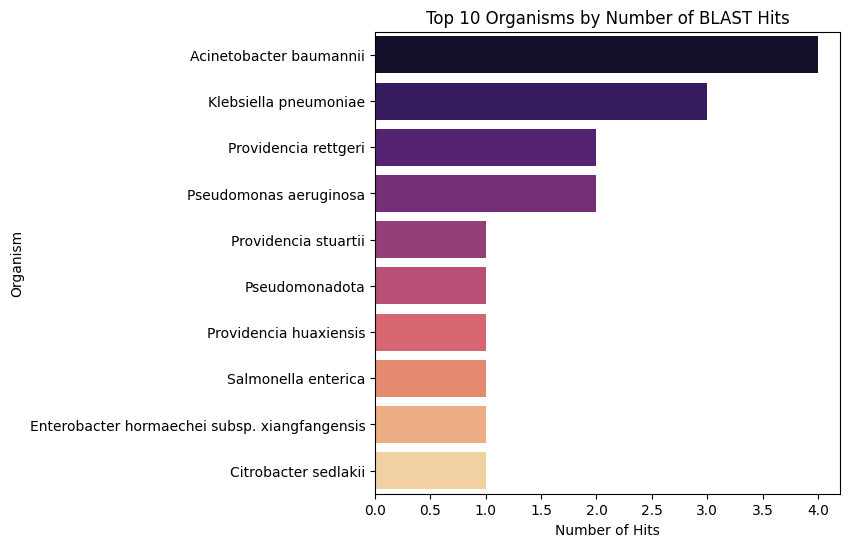

In [10]:
plt.figure(figsize=(6, 6))
top_organisms = df['Organism'].value_counts().head(10)
sns.barplot(x=top_organisms.values,hue = top_organisms.index, y= top_organisms.index, palette='magma')
plt.title('Top 10 Organisms by Number of BLAST Hits')
plt.xlabel('Number of Hits')
plt.ylabel('Organism')
plt.show()

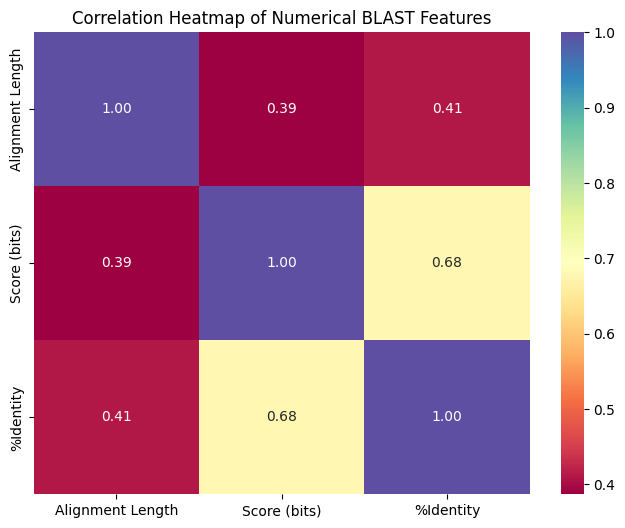

In [11]:
plt.figure(figsize=(8, 6))
numerical_cols = ['Alignment Length', 'Score (bits)', '%Identity']
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='Spectral', fmt='.2f')
plt.title('Correlation Heatmap of Numerical BLAST Features')
plt.show()

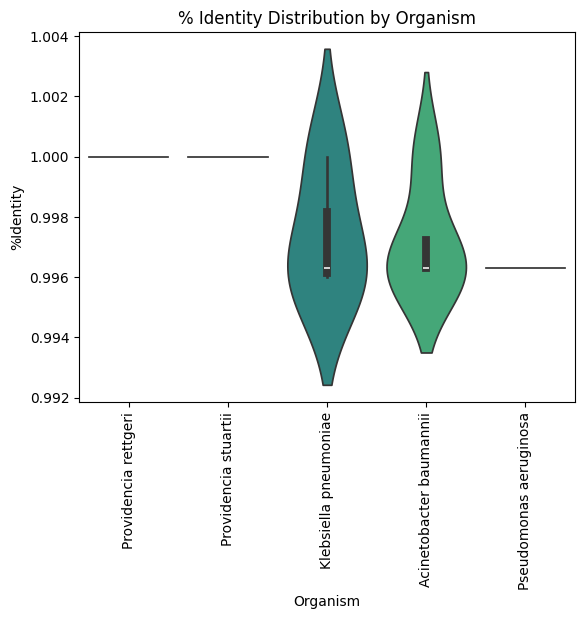

In [12]:
top_5_orgs = df['Organism'].value_counts().head(5).index
sns.violinplot(data=df[df['Organism'].isin(top_5_orgs)], x='Organism',hue = "Organism", y='%Identity', palette='viridis')
plt.title("% Identity Distribution by Organism")
plt.xticks(rotation=90)
plt.show()

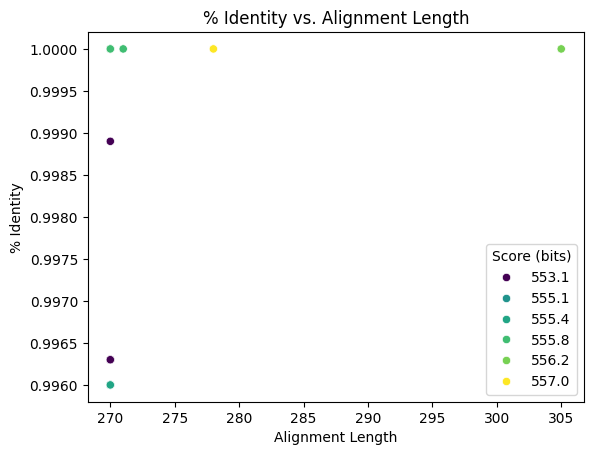

In [13]:
sns.scatterplot(data=df, x='Alignment Length', y='%Identity', hue='Score (bits)', palette='viridis')
plt.title("% Identity vs. Alignment Length")
plt.xlabel("Alignment Length")
plt.ylabel("% Identity")
plt.show()

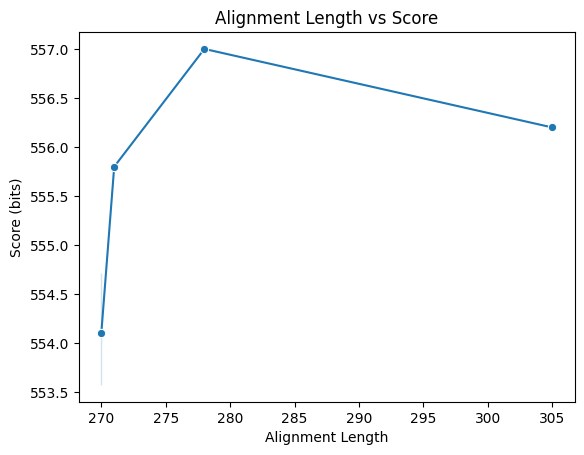

In [14]:
sns.lineplot(
    data=df.sort_values("Alignment Length"),
    x="Alignment Length", y="Score (bits)", marker='o' 
)
plt.title("Alignment Length vs Score")
plt.show()


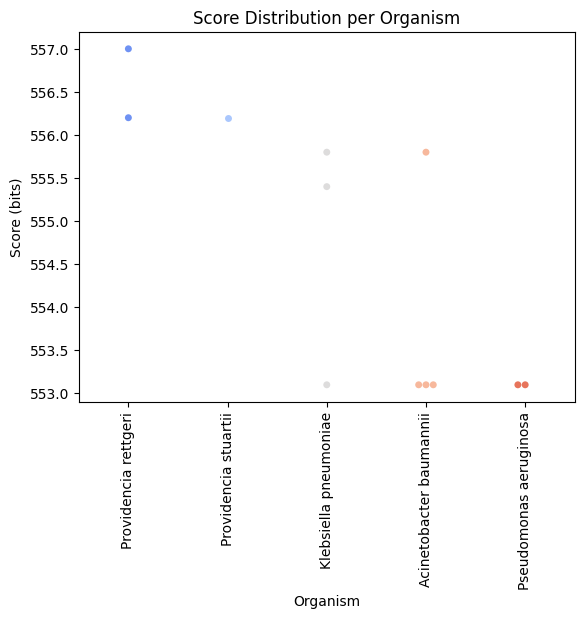

In [15]:
sns.swarmplot(
    data=df[df['Organism'].isin(top_5_orgs)],
    x='Organism', y='Score (bits)',hue = "Organism", palette='coolwarm'
)
plt.title("Score Distribution per Organism")
plt.xticks(rotation=90)
plt.show()


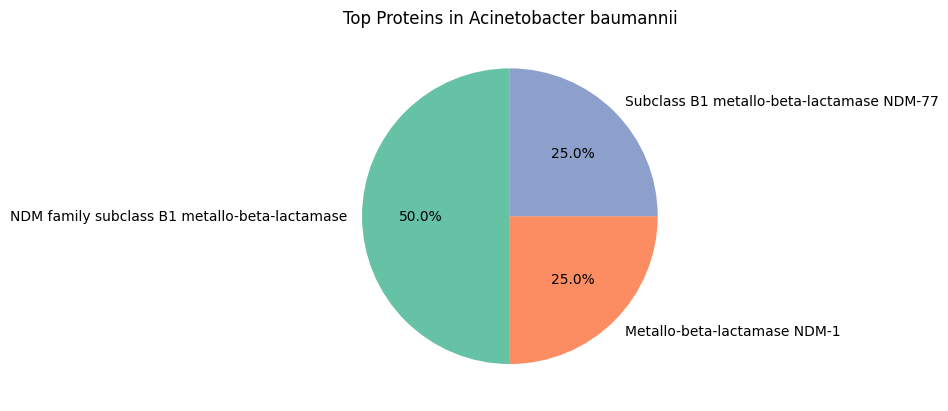

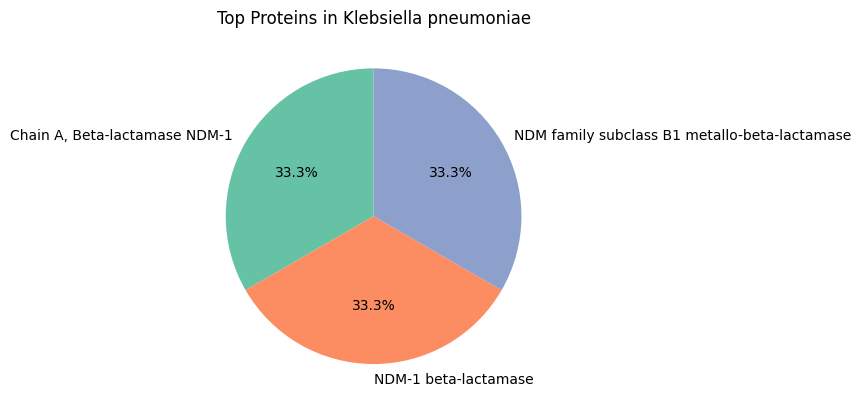

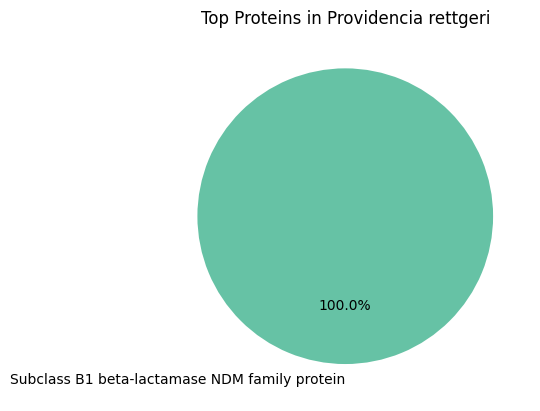

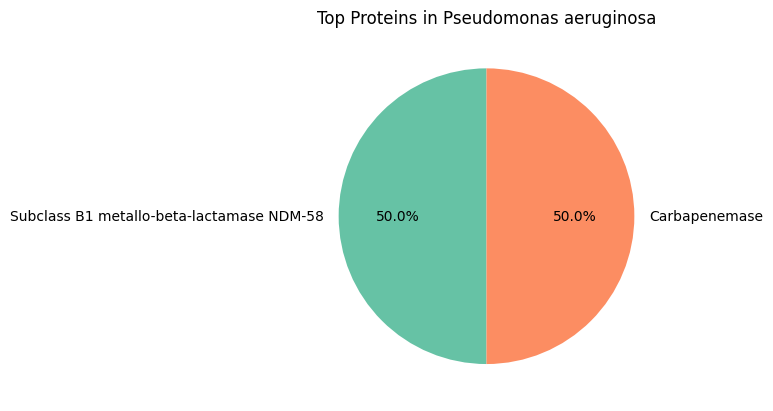

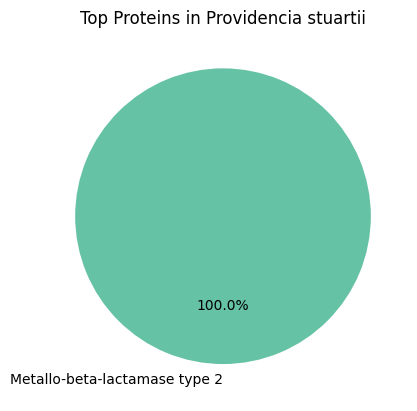

In [16]:
top_3_orgs = df['Organism'].value_counts().head(5).index

for org in top_3_orgs:
    df[df['Organism'] == org]['Protein name'].value_counts().head(20).plot.pie(
        autopct='%1.1f%%', startangle=90, ylabel="", colors=sns.color_palette('Set2')
    )
    plt.title(f"Top Proteins in {org}")
    plt.show()

# <span style="color:darkblue;">**Conclusion: NDM-Family Metallo-Beta-Lactamase Sequence Analysis**</span>

In this project, we analyzed the BLAST hit dataset for **NDM-family subclass B1 metallo-beta-lactamases** across multiple bacterial species to uncover insights into **sequence conservation, organism distribution, and protein characteristics**. The dataset included dimensions such as **organism**, **protein name**, **sequence ID**, **%Identity**, **bit score**, and **alignment length**.  

---

## <span style="color:darkgreen;">**Key Findings:**</span>

- **<span style="color:purple;">Dominant organisms:</span>** *Pseudomonas aeruginosa*, *Acinetobacter baumannii*, and *Escherichia coli* dominate the hits, as visualized in **bar charts and pie charts**, indicating they are the **primary carriers of NDM-family proteins**.  
- **<span style="color:purple;">High sequence conservation:</span>** Sequence identity is extremely high (**99–100%**) with very low **E-values**, highlighting **strong evolutionary conservation** across different bacteria.  
- **<span style="color:purple;">Similarity patterns:</span>** Heatmaps show **conserved patterns among bacterial species**, suggesting shared NDM sequences and potential **horizontal gene transfer**.  
- **<span style="color:purple;">Consistent proteins:</span>** A small number of proteins appear **consistently across multiple organisms**, confirming the **conserved nature of NDM-family metallo-beta-lactamases**.

---

## <span style="color:darkgreen;">**Recommendations:**</span>

- Focus research on **highly prevalent organisms** to develop **targeted antibiotic resistance strategies**.  
- Monitor **sequence variations** in emerging bacterial strains for early detection of **new resistance genes**.  
- Explore **phylogenetic relationships** and **evolutionary trends** to better understand NDM gene dissemination.  

---

## <span style="color:darkred;">**Limitations:**</span>

- Analysis is based on **static BLAST hits**; it does not include **temporal trends or emerging mutations**.  
- Only the **top hits** were considered; rare variants might be overlooked.  

---

## <span style="color:darkorange;">**Future Scope:**</span>

- Perform **phylogenetic analysis** to explore evolutionary relationships.  
- Integrate **resistance phenotype data** to correlate sequence variation with functional impact.  
- Use **clustering or network analysis** to identify patterns of gene sharing between bacterial species.  
- Extend analysis to **time-series or epidemiological data** for surveillance purposes.  

**Analysis completed using Python (Pandas, Seaborn, Matplotlib, Seaborn heatmaps).**
